# Activity Data Visualization

This notebook contains the process followed to visualize activity.

Below, necessary libraries are imported data processing, analysis and visualization.

In [1]:
# Standard library
import json
import re

# External requests
import requests

# Data analysis
import numpy as np
import pandas as pd

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

# Seaborn
import seaborn as sns

# iPyWidgets
import ipywidgets as widgets
from IPython.display import display

# Plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Global notebook style
pio.renderers.default = "notebook_connected"
sns.set_theme(style="whitegrid")
plt.style.use("default")
plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.2,
    "grid.linestyle": "--",
    "grid.alpha": 0.3
})

## 1. Reading the Data

The data comes from a Garmin Forerunner 245 watch that has recorded activities for around 5 years. It can be downloaded using the Garmin Connect's dashpage into a CSV format.

The data is loaded from the `Activities.csv` file that should be located in the same directory as this notebook.

In [2]:
df = pd.read_csv("data/activities.csv")
print(f"Raw shape: {df.shape}")
print("\nFirst rows:")
df.head(3)

Raw shape: (180, 31)

First rows:


,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Steps,Total Reps,Total Sets,Decompression,Best Lap Time,Number of Laps,Moving Time,Elapsed Time,Min Elevation,Max Elevation
0,Walking,2026-03-19 20:04:39,False,Majadahonda Walking,6.41,472,01:06:17,120,150,3.1,...,"7,482",--,--,No,00:04:16.7,7,01:06:04,01:06:17,677,750
1,Walking,2026-03-18 10:46:40,False,Majadahonda Walking,1.64,103,00:17:40,124,142,1.0,...,"1,968",--,--,No,00:06:52.3,2,00:17:40,00:17:40,679,722
2,Trail Running,2026-03-18 10:13:00,False,Majadahonda - R20 W04 (02:00),3.48,268,00:33:08,140,166,2.6,...,"4,230",--,--,No,00:00:07.8,17,00:33:07,00:33:08,716,750


## 2. Understanding the data

By using the function `df.info()` we can see dataframe column information, which showcases the following:

- 31 different columns.
- Default types set to `str`, `bool`, `float64`, `int64`.
- Some columns seem to have the wrong data type (`Distance` having `str` even most of its values are numeric).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Activity Type           180 non-null    str    
 1   Date                    180 non-null    str    
 2   Favorite                180 non-null    bool   
 3   Title                   180 non-null    str    
 4   Distance                180 non-null    str    
 5   Calories                180 non-null    str    
 6   Time                    180 non-null    str    
 7   Avg HR                  180 non-null    str    
 8   Max HR                  180 non-null    str    
 9   Aerobic TE              180 non-null    str    
 10  Avg Cadence             180 non-null    str    
 11  Max Cadence             180 non-null    str    
 12  Avg Pace                180 non-null    str    
 13  Best Pace               180 non-null    str    
 14  Total Ascent            180 non-null    str    
 15  

### 2.1 AI Analysis

I gave AI the following prompt to create me a table indicating it's suggested analysis of the data:

> Read the linked CSV file and analyze it, create a table with the following fields:
> 
> - Nº: Column number.
> - Column: Column name.
> - Description: Content description (what the data in the column usually looks like, excluding null indicators).
> - Null indicator: Indicator that seems to be used for when data is null.
> - Data type: Suggested data type to be used when reading CSV in Pandas.
qwen3.5-9b

The AI then printed me the following table:

| Nº | Column               | Description                                                                                   | Null indicator | Data type         |
|----|----------------------|-----------------------------------------------------------------------------------------------|----------------|------------------|
| 1  | Activity Type        | Indicates the type of activity (e.g., Walking, Trail Running)                                  | --             | categorical       |
| 2  | Date                 | Timestamp indicating when the activity started                                                 | --             | datetime64[ns]    |
| 3  | Favorite             | Boolean value indicating if the activity is marked as a favorite                               | false          | boolean           |
| 4  | Title                | Name of the activity                                                                           | "Majadahonda Walking", etc. | string |
| 5  | Distance             | Total distance covered during the activity                                                      | --             | float64           |
| 6  | Calories             | Number of calories burned during the activity                                                   | --             | int64             |
| 7  | Time                 | Duration of the activity (hh:mm:ss)                                                            | --             | timedelta64      |
| 8  | Avg HR               | Average heart rate during the activity                                                          | --             | float64           |
| 9  | Max HR               | Maximum heart rate reached during the activity                                                  | --             | int64             |
| 10 | Aerobic TE           | Total energy expenditure from aerobic exercise                                                  | --             | float64           |
| 11 | Avg Cadence          | Average cadence (number of steps per minute)                                                    | --             | int64             |
| 12 | Max Cadence          | Maximum cadence reached during the activity                                                     | --             | int64             |
| 13 | Avg Pace            | Average pace of the activity in minutes per kilometer                                           | --             | timedelta64      |
| 14 | Best Pace           | Best pace achieved during the activity                                                           | --             | timedelta64      |
| 15 | Total Ascent         | Total ascent climbed during the activity                                                        | --             | float64           |
| 16 | Total Descent        | Total descent descended during the activity                                                     | --             | float64           |
| 17 | Avg Stride Length    | Average stride length during the activity                                                       | --             | float64           |
| 18 | Training Stress Score®| A score indicating overall stress on the body due to exercise                                 | --             | float64           |
| 19 | Total Strokes        | Number of strokes if applicable (swimming)                                                     | --             | int64             |
| 20 | Avg. Swolf           | Average swimming efficiency metric (synchronization of stroke and frequency)                    | --             | float64           |
| 21 | Avg Stroke Rate      | Average number of strokes per minute                                                            | --             | float64           |
| 22 | Steps                | Total number of steps taken during the activity                                                 | --             | int64             |
| 23 | Total Reps           | Total repetitions if applicable (strength training)                                            | --             | int64             |
| 24 | Total Sets           | Total sets if applicable (strength training)                                                    | --             | int64             |
| 25 | Decompression        | Indicates whether decompression was needed                                                      | No             | boolean           |
| 26 | Best Lap Time        | Best lap time achieved during the activity                                                     | "00:04:16.7", etc. | timedelta64      |
| 27 | Number of Laps       | Total number of laps completed                                                                 | --             | int64             |
| 28 | Moving Time          | The total moving time (excluding pauses)                                                        | "01:06:04"     | timedelta64      |
| 29 | Elapsed Time         | Total elapsed time including stops                                                             | "01:06:17"     | timedelta64      |
| 30 | Min Elevation        | Minimum elevation reached during the activity                                                   | --             | int64             |
| 31 | Max Elevation        | Maximum elevation reached during the activity                                                   | --             | int64             |

Although not perfect, this gives us a good starting point on cleaning up the data and having it be more readable. Some mistakes we can catch at first glanse from the analysis are the following:

- **Favorite:** `false` isn't necessarily a Null value, just means it hasn't been indicated.
- **Title:** Null indicator is clearly wrong (`"Majadahonda Walking"`is just a commonly used title).
- **Aerobic TE:** Didn't expect AI to get it right, it is [calculated based off training condition](https://www.garmin.com/en-US/garmin-technology/running-science/physiological-measurements/aerobic-training-effect/).
- **Decompression:** No doesn't necessarily mean its Null, just means it hasn't been indicated, could be changed to `True` and `False`.
- **Best Lap Time, Moving Time, Elapsed Time:** Null indicator clearly wrong, just a common time given.

## 3. Cleaning data

Below are a couple steps taken to clean the data based off of the analysis the AI did.

On top of this, some extra fields were added due to the questions being answer, explained as follows:

#### Question-Specific Feature Engineering

For some of the questions being asked about the dataset, new fields need to be created to be able to answer specific questions.

- `Week` and `Year` can be extracted from the `df['Date']` column.
- Simplify different running activities to the same `Activity Type`.
- `Intensity` can be extraced from `Avg HR` having 140 bpm as the differentiator between `Moderate` and `Vigorous` activity.
- `Location` can be extracted from `Title` but I'm unsure of the regex pattern that would have to be used, since it's a complex one due to title being in many different formats.



### 3.1 Drop Unused Columns
Remove 20+ columns not used in analysis (laps, cadence, stress score, etc.).

In [4]:
unused_cols = [
    'Favorite', 'Total Reps', 'Total Sets', 'Decompression', 'Best Lap Time',
    'Avg Cadence', 'Total Strokes', 'Avg. Swolf', 'Elapsed Time', 
    'Number of Laps', 'Avg Stroke Rate', 'Avg Stride Length', 'Max Cadence',
    'Training Stress Score®', 'Moving Time', 'Activity_Group', 'Avg Pace',
    'Best Pace', 'Min Elevation', 'Max Elevation', 'Total Ascent', 'Total Descent'
]
df = df.drop(columns=[col for col in unused_cols if col in df.columns], errors='ignore')
print(f"After drops: {df.shape}")

After drops: (180, 10)


### 3.2 Standardize Missing Values
Replace '--' placeholders with NaN for consistent handling.

In [5]:
df = df.replace('--', np.nan)

### 3.3 Clean Numeric Columns
Remove commas from Calories/Steps/Distance, convert to numeric.

In [6]:
for col in ["Calories", "Steps", "Distance", "Avg HR", "Max HR", "Aerobic TE"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors='coerce')

### 3.4 Parse Dates & Time
Convert Date/Time strings → proper datetime/timedelta.

In [7]:
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
if 'Time' in df.columns:
    df['Time'] = pd.to_timedelta(df['Time'], errors='coerce')

### 3.5 Add Time Features
Extract Year, Week, convert Time → Time_min for analysis.

In [8]:
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week
df['Time_min'] = df['Time'].dt.total_seconds().fillna(0) / 60

### 3.6 Simplify Activity Types
Merge Treadmill/Trail Running → Running, make categorical.

In [9]:
df['Activity Type'] = df['Activity Type'].astype(str).replace({
    'Treadmill Running': 'Running',
    'Trail Running': 'Running'
})
df['Activity Type'] = pd.Categorical(df['Activity Type'])
print("Activity types:", df['Activity Type'].cat.categories.tolist())

Activity types: ['Canoeing', 'Cycling', 'Pilates', 'Pool Swim', 'Running', 'Strength Training', 'Walking']


### 3.7 WHO Intensity Metrics
Classify Moderate (<140 bpm) vs Vigorous, compute WHO_equiv minutes.

In [10]:
df['Intensity'] = pd.cut(df.get('Avg HR', 0), bins=[-np.inf, 140, np.inf], 
                        labels=['Moderate', 'Vigorous'])
df['WHO_equiv'] = np.where(df['Intensity'] == 'Vigorous', 
                          df['Time_min'] * 2, df['Time_min'])

### 3.8 Extract Locations

To extract location, AI was prompted with the following prompt:

> You are a regex expert. From Garmin fitness 'Title' column, extract geographic location (Madrid-> area places) before route/activity suffixes.
>
> Examples (input -> desired output):
> - "Majadahonda Walking" -> "Majadahonda"
> - "Majadahonda - R20 W04 (02:00)" -> "Majadahonda"
> - "Boadilla del Monte - Week 3 Running" -> "Boadilla del Monte"
> - "Las Rozas de Madrid Walking" -> "Las Rozas de Madrid"
> - "Treadmill Running" -> None
> - "Pool Swimming" -> None
>
> Give ONE pandas str.extract(r'...') regex:
>
> - Multi-word, spaces/dashes/accents.
> - Stops at first '- [route]' or activity keyword (Walking, Running, etc.).
> - NaN for non-places.
> 
> Test on examples with output table.
qwen3.5-9b

For which the following regex string was theorized:

`r'^(.*?)(?:\s+(Walking|Running|Swimming|Cycling|Treadmill|\bPool\b)|-)'`

Unfortunately this meant that "Treadmill" and "Pool" were treated as locations too, so they were manually filtered for and replaced with `None`.

In [11]:
df['Location'] = df['Title'].str.extract(r'^(.*?)(?:\s+(Walking|Running|Swimming|Cycling|Treadmill|\bPool\b)|-)')[0].str.strip()
df['Location'] = df['Location'].where(~df['Location'].isin(['Treadmill', 'Pool', '', pd.NA]))
print("Locations:", df['Location'].value_counts().head())

Locations: Location
Majadahonda           70
Pozuelo de Alarcón    51
Boadilla del Monte    17
Madrid                 5
Sanxenxo               4
Name: count, dtype: int64


### 3.9 Precompute Weekly Summary
Group by Year/Week/Intensity for later analysis.

In [12]:
weekly = df.groupby(['Year', 'Week', 'Intensity'])['WHO_equiv'].sum().reset_index()
print(f"Weekly summary: {weekly.shape}")
print(weekly.head())

Weekly summary: (70, 4)
   Year  Week Intensity   WHO_equiv
0  2021     5  Vigorous   76.833333
1  2021     6  Vigorous  224.333333
2  2021     7  Vigorous  185.566667
3  2021     8  Vigorous  213.023333
4  2021     9  Vigorous   70.000000


## 4. Visualizations

To prepare for the visualizations, a function defining a cohesive theme is declared underneath first. 

In [13]:
# Color palette
COLORS = {
    "success": "#10b981",      # Green: met WHO target (≥150)
    "below": "#94a3b8",        # Gray: below target
    "accent": "#0d9488",       # Teal: titles, targets, emphasis
    "grid": "#e2e8f0",         # Light grid
    "text": "#475569",         # Muted labels/ticks
    "bg": "#f8fafc",           # Figure background
    "deep_green": "#047857",   # Darker green variant
    "light_green": "#a7f3d0",   # Lighter green variant
}

# Themeing function
def apply_theme(ax, despine_left=False):
    ax.set_facecolor(COLORS["bg"])
    ax.tick_params(colors=COLORS["text"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(COLORS["grid"])
    ax.spines["bottom"].set_color(COLORS["grid"])
    ax.xaxis.label.set_color(COLORS["accent"])
    ax.yaxis.label.set_color(COLORS["accent"])
    ax.title.set_color(COLORS["accent"])
    ax.grid(True, alpha=0.3, color=COLORS["grid"])
    if despine_left:
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", which="both", left=False)


### 4.1 Q1 – What does my activity mix look like?

Over roughly 5 years of tracking, the dataset captures 7 distinct activity types.
This section looks at how training time is distributed across them — which activities
dominate, and which are occasional. Understanding the composition is a prerequisite
for the deeper questions in Q2 and Q3.

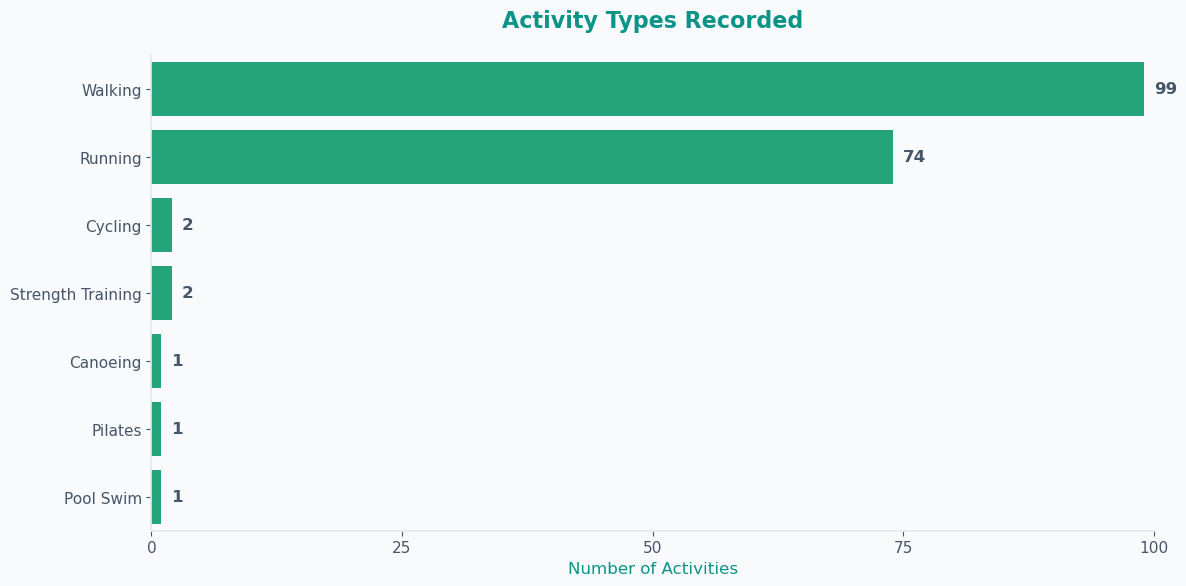

In [14]:
counts = df['Activity Type'].value_counts().reset_index()
counts.columns = ['Activity Type', 'Count']
order = counts['Activity Type'].tolist()

fig, ax = plt.subplots(figsize=(12, 6), facecolor=COLORS["bg"])

sns.barplot(
    data=counts,
    y='Activity Type',
    x='Count',
    order=order,
    color=COLORS["success"],
    linewidth=1.5,
    ax=ax
)

offset = counts['Count'].max() * 0.01
for i, row in enumerate(counts.itertuples()):
    ax.text(
        row.Count + offset, i, f'{int(row.Count)}',
        va='center', ha='left',
        fontweight='bold', fontsize=12,
        color=COLORS["text"]
    )

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_ylabel('')
ax.set_xlabel('Number of Activities', fontsize=12)
ax.set_title('Activity Types Recorded', fontsize=16, fontweight='bold', pad=20)
apply_theme(ax)
ax.grid(False)
    
plt.tight_layout()
plt.show()

### 4.2 Q2 - Weekly training consistency

This section explores how training volume changes over time and whether the WHO weekly activity target is consistently met.

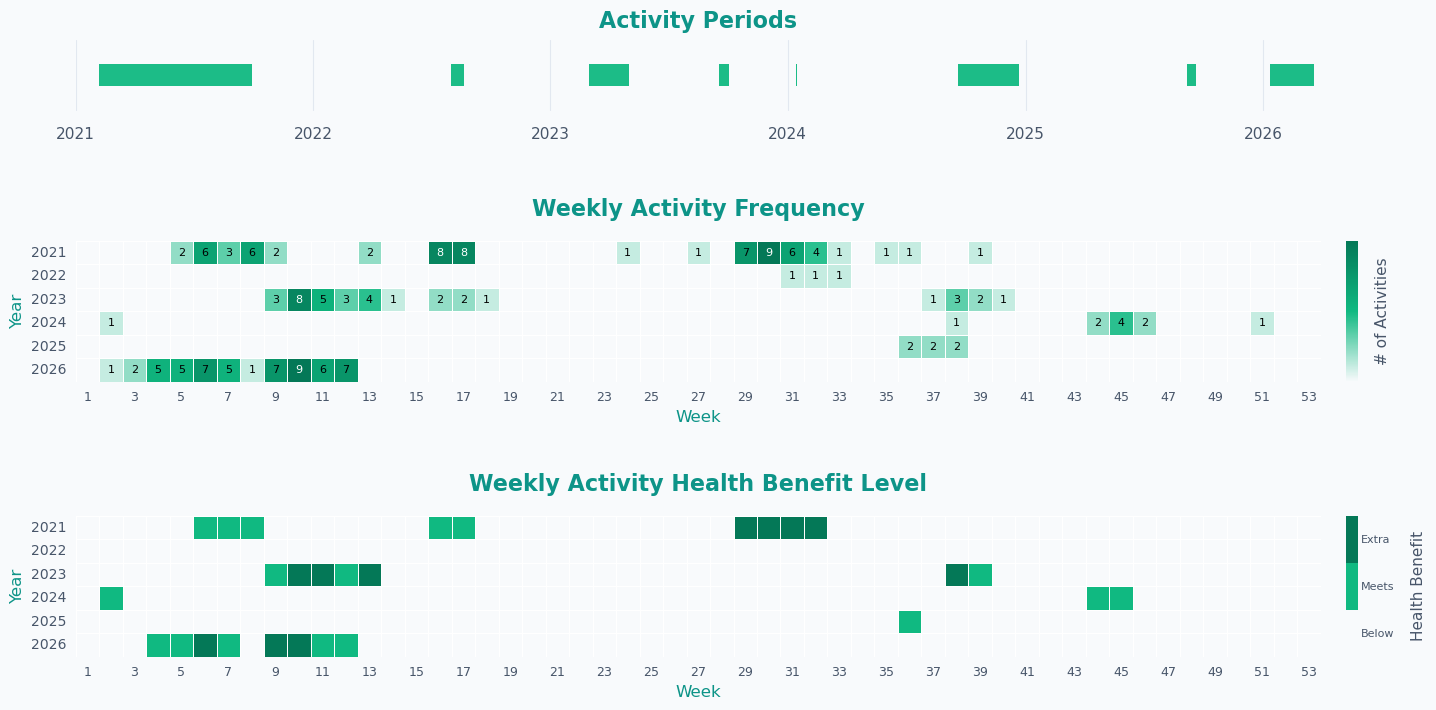

In [72]:
# -----------------------------
# 1. Precompute both heatmap tables
# -----------------------------
weekly_count = (
    df.groupby(["Year", "Week"])
      .size()
      .reset_index(name="Activity_Count")
)

pivot_count = (
    weekly_count.pivot(index="Year", columns="Week", values="Activity_Count")
                .reindex(columns=range(1, 54))
                .fillna(0)
                .astype(float)
)

weekly_intensity = (
    df.groupby(["Year", "Week"])["WHO_equiv"]
      .sum()
      .reset_index()
)

pivot_who = (
    weekly_intensity.pivot(index="Year", columns="Week", values="WHO_equiv")
                    .reindex(columns=range(1, 54))
                    .fillna(0)
                    .astype(float)
)

# -----------------------------
# 2. Build activity periods
# -----------------------------
period_df = df.copy()
period_df["Date"] = pd.to_datetime(period_df["Date"], errors="coerce")
period_df = period_df.sort_values("Date").reset_index(drop=True)

period_df["Gap_Days"] = period_df["Date"].diff().dt.days
period_df["New_Period"] = period_df["Gap_Days"].isna() | (period_df["Gap_Days"] > 60)
period_df["Period_ID"] = period_df["New_Period"].cumsum()

period_summary = (
    period_df.groupby("Period_ID")
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        Activities=("Date", "count")
    )
    .reset_index()
)

period_summary["Duration_Days"] = (
    period_summary["End_Date"] - period_summary["Start_Date"]
).dt.days + 1

period_summary = period_summary.sort_values("Start_Date").reset_index(drop=True)
period_summary["Period_Label"] = [f"P{i}" for i in range(1, len(period_summary) + 1)]

# -----------------------------
# 3. Colormap settings
# -----------------------------
count_colors = [COLORS["bg"], COLORS["success"], COLORS["deep_green"]]
count_cmap = LinearSegmentedColormap.from_list(
    "activity_count_gradient",
    count_colors,
    N=256
)

who_colors = [COLORS["bg"], COLORS["success"], COLORS["deep_green"]]
who_cmap = ListedColormap(who_colors)

who_max = pivot_who.to_numpy().max()
who_bounds = [0, 150, 300, who_max + 1]
who_norm = BoundaryNorm(who_bounds, who_cmap.N)

who_tick_positions = [
    (0 + 150) / 2,
    (150 + 300) / 2,
    (300 + (who_max + 1)) / 2
]

# -----------------------------
# 4. Create figure with fully manual axis placement
# -----------------------------
plt.close("all")
sns.set_style("white")

fig = plt.figure(figsize=(15, 11), facecolor=COLORS["bg"])

left = 0.06
right_edge = 0.91
width = right_edge - left
cbar_width = 0.012
cbar_pad = 0.008
heatmap_width = width - cbar_width - cbar_pad

gap_top_mid = 0.025
gap_mid_bot = -0.05
top_h = 0.08
heat_h = 0.30
bottom = 0.06

bottom_ax_bottom = bottom
bottom_ax_middle = bottom_ax_bottom + heat_h + gap_mid_bot
bottom_ax_top    = bottom_ax_middle + heat_h + gap_top_mid
top_total_width = heatmap_width + cbar_pad + cbar_width

ax_top    = fig.add_axes([left, bottom_ax_top, heatmap_width, top_h])
ax_middle = fig.add_axes([left, bottom_ax_middle, heatmap_width, heat_h])
ax_bottom = fig.add_axes([left, bottom_ax_bottom, heatmap_width, heat_h])

cbar_ax_middle = ax_middle.inset_axes([1.02, 0, 0.01, 1.0])
cbar_ax_bottom = ax_bottom.inset_axes([1.02, 0, 0.01, 1.0])

# -----------------------------
# 5. Top chart: Activity periods timeline
# -----------------------------
for i, row in period_summary.iterrows():
    start_num = mdates.date2num(row["Start_Date"])
    duration = row["Duration_Days"]

    ax_top.barh(
        y=0,
        width=duration,
        left=start_num,
        height=0.025,
        color=COLORS["success"],
        edgecolor="none",
        alpha=0.95
    )

ax_top.set_yticks([])
ax_top.xaxis_date()
ax_top.xaxis.set_major_locator(mdates.YearLocator())
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_top.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
apply_theme(ax_top)
ax_top.set_xlim(
    mdates.date2num(pd.Timestamp("2021-01-01")),
    mdates.date2num(pd.Timestamp("2026-03-31"))
)
ax_top.set_xlabel("")
ax_top.set_title("Activity Periods", fontsize=16, fontweight="bold", color=COLORS["accent"], pad=2)
ax_top.set_ylim(-0.05, 0.05)
ax_top.grid(False)

for spine in ax_top.spines.values():
    spine.set_visible(False)

for year in range(2021, 2027):
    ax_top.axvline(
        mdates.date2num(pd.Timestamp(f"{year}-01-01")),
        ymin=0.1,
        ymax=0.9,
        color=COLORS["grid"],
        linewidth=0.8,
        zorder=0
    )

ax_top.tick_params(axis="x", length=0, pad=6)

# -----------------------------
# 6. Middle heatmap: Activity count
# -----------------------------
sns.heatmap(
    pivot_count,
    cmap=count_cmap,
    ax=ax_middle,
    cbar=False,
    linewidths=0.6,
    linecolor="white",
    xticklabels=2,
)
ax_middle.set_aspect("equal")

for i in range(pivot_count.shape[0]):
    for j in range(pivot_count.shape[1]):
        value = int(pivot_count.iloc[i, j])
        if value > 0:
            text_color = "white" if value >= 8 else "black"
            ax_middle.text(
                j + 0.5,
                i + 0.5,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=8
            )

cbar1 = fig.colorbar(ax_middle.collections[0], cax=cbar_ax_middle)
cbar1.set_ticks([])
cbar1.ax.minorticks_off()
cbar1.ax.tick_params(which="both", length=0)
cbar1.outline.set_visible(False)
cbar1.set_label("# of Activities", color=COLORS["text"], labelpad=12)
cbar1.ax.yaxis.label.set_color(COLORS["text"])
cbar1.ax.tick_params(colors=COLORS["text"])

apply_theme(ax_middle)
ax_middle.set_title("Weekly Activity Frequency", fontsize=16, fontweight="bold", pad=18)
ax_middle.set_xlabel("Week", fontsize=12)
ax_middle.set_ylabel("Year", fontsize=12)
ax_middle.tick_params(axis="x", colors=COLORS["text"], labelsize=9)
ax_middle.tick_params(axis="y", colors=COLORS["text"], labelsize=10, labelrotation=0)
ax_middle.grid(False)

# -----------------------------
# 7. Bottom heatmap: WHO-equivalent
# -----------------------------
sns.heatmap(
    pivot_who,
    cmap=who_cmap,
    norm=who_norm,
    ax=ax_bottom,
    cbar=False,
    linewidths=0.6,
    linecolor="white",
    xticklabels=2,
)
ax_bottom.set_aspect("equal")

cbar2 = fig.colorbar(ax_bottom.collections[0], cax=cbar_ax_bottom, norm=who_norm)
cbar2.set_ticks(who_tick_positions)
cbar2.set_ticklabels(["Below", "Meets", "Extra"])
cbar2.ax.minorticks_off()
cbar2.ax.tick_params(which="minor", length=0)
cbar2.ax.tick_params(
    which="major",
    length=0,
    colors=COLORS["text"],
    labelsize=8,
    pad=2
)
cbar2.outline.set_visible(False)
cbar2.set_label("Health Benefit", color=COLORS["text"], labelpad=12)
cbar2.ax.yaxis.label.set_color(COLORS["text"])
cbar2.ax.tick_params(colors=COLORS["text"])

apply_theme(ax_bottom)
ax_bottom.set_title("Weekly Activity Health Benefit Level", fontsize=16, fontweight="bold", pad=18)
ax_bottom.set_xlabel("Week", fontsize=12)
ax_bottom.set_ylabel("Year", fontsize=12)
ax_bottom.tick_params(axis="x", colors=COLORS["text"], labelsize=9)
ax_bottom.tick_params(axis="y", colors=COLORS["text"], labelsize=10, labelrotation=0)
ax_bottom.grid(False)

plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

def plot_lollipop(year):
    plt.close("all")

    weekly = (
        df[df["Year"] == year]
        .groupby("Week")["WHO_equiv"]
        .sum()
        .reindex(range(1, 54), fill_value=0)
        .rename_axis("Week")
        .reset_index()
    )

    weekly["Year"] = year
    weekly["Enough150"] = weekly["WHO_equiv"] >= 150
    weekly["Enough300"] = weekly["WHO_equiv"] >= 300

    active_weeks = weekly[weekly["WHO_equiv"] > 0]

    fig, ax = plt.subplots(figsize=(12, 6), facecolor=COLORS["bg"])
    ax.set_facecolor(COLORS["bg"])

    for _, row in active_weeks.iterrows():
        if row["WHO_equiv"] >= 300:
            color = COLORS["deep_green"]
        elif row["WHO_equiv"] >= 150:
            color = COLORS["success"]
        else:
            color = COLORS["below"]

        ax.vlines(
            x=row["Week"],
            ymin=0,
            ymax=row["WHO_equiv"],
            color=color,
            linewidth=4,
            alpha=0.75
        )

        ax.scatter(
            row["Week"],
            row["WHO_equiv"],
            s=120,
            color=color,
            alpha=0.9,
            zorder=3
        )

    ax.axhline(
        150,
        color=COLORS["accent"],
        lw=2.5,
        ls="--",
        label="WHO Target (150 min/week)"
    )

    ax.axhline(
        300,
        color=COLORS["deep_green"],
        lw=2.5,
        ls=":",
        label="Enhanced Target (300 min/week)"
    )

    ax.set_xlim(0.5, 53.5)
    ax.set_xticks(range(1, 54))

    ax.set_ylim(0, 800)
    ax.set_yticks([0, 150, 300, 450, 600, 750])

    ax.set_xlabel(f"ISO Week ({year})", fontsize=12)
    ax.set_ylabel("Total Weekly WHO-Equivalent Minutes", fontsize=12)

    ax.set_title(
        f"Weekly WHO-Equivalent Intensity vs Target ({year})",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    apply_theme(ax, despine_left=False)
    ax.grid(False)
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

year_selector = widgets.Dropdown(
    options=sorted(df["Year"].dropna().unique()),
    value=sorted(df["Year"].dropna().unique())[-1],
    description="Year"
)

out = widgets.interactive_output(plot_lollipop, {"year": year_selector})
display(year_selector, out)

In [ ]:
recent_2026 = df[df['Year'] == 2026].copy()
weekly_trend = recent_2026.groupby('Week')['WHO_equiv'].sum().reset_index()
weekly_trend['Week_Seq'] = range(1, len(weekly_trend) + 1)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

# Regression line only (no scatter)
sns.regplot(
    data=weekly_trend,
    x='Week_Seq',
    y='WHO_equiv',
    scatter=False,  # Disable auto scatter
    line_kws={'color': COLORS["accent"], 'lw': 3},
    ax=ax
)

# Manual scatter with conditional colors
below_target = weekly_trend['WHO_equiv'] < 150
ax.scatter(
    weekly_trend.loc[~below_target, 'Week_Seq'], 
    weekly_trend.loc[~below_target, 'WHO_equiv'], 
    s=120, alpha=0.8, color=COLORS["success"], zorder=3, label='Above target'
)
ax.scatter(
    weekly_trend.loc[below_target, 'Week_Seq'], 
    weekly_trend.loc[below_target, 'WHO_equiv'], 
    s=120, alpha=0.8, color=COLORS["below"], zorder=3, label='Below target'
)

who_target = 150
ax.axhline(
    who_target,
    color=COLORS["accent"],
    lw=2,
    ls="--",
    label=f"WHO Target: {who_target} min/week"
)

ax.set_xticks(weekly_trend['Week_Seq'])
ax.set_xticklabels(weekly_trend['Week'])

ax.set_xlabel('ISO Week (2026 Training Block)', fontsize=12)
ax.set_ylabel('WHO-Equivalent Minutes', fontsize=12)
ax.set_title(
    '2026 Training Trajectory: Weekly Activity Trend',
    fontsize=15,
    fontweight='bold'
)

apply_theme(ax)

ax.grid(axis='both', alpha=0.3, color=COLORS["grid"])
ax.legend()

plt.tight_layout()
plt.show()

### 4.3 Q3 – Where do I train, and does location vary by activity type?

Most activities are clustered around a few municipalities in the Madrid region,
but the dataset also captures trips to Galicia, Asturias, and Catalonia.
This section maps activity counts geographically at two scales: first at the
autonomous community level across Spain, then zoomed into the Madrid municipalities
where the majority of training takes place.

#### GeoJSON

The choropleth requires polygon boundaries for Spain's autonomous communities.
The GeoJSON is fetched from a public GitHub repository and saved locally, executing
this cell once prevents spamming requests and risking not having availability for
the data.

In [ ]:
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"
r = requests.get(url, timeout=30)
r.raise_for_status()

with open("spain_communities.geojson", "w", encoding="utf-8") as f:
    f.write(r.text)

print("GeoJSON saved successfully.")

In [ ]:
# --------------------------------------------------
# Your data
# --------------------------------------------------
bad_locations = {"Walking", "Running", "Cycling", "Swimming", "Pool", "Treadmill"}
spain_df = df[df["Location"].notna() & ~df["Location"].isin(bad_locations)].copy()

community_map = {
    "Majadahonda": "Community of Madrid",
    "Pozuelo de Alarcón": "Community of Madrid",
    "Boadilla del Monte": "Community of Madrid",
    "Las Rozas de Madrid": "Community of Madrid",
    "Madrid": "Community of Madrid",
    "Alcobendas": "Community of Madrid",
    "Villanueva de la Cañada": "Community of Madrid",
    "Rascafría": "Community of Madrid",
    "Sanxenxo": "Galicia",
    "Gijón": "Asturias",
    "Villaviciosa": "Asturias",
    "Ribadesella": "Asturias",
    "El Vendrell": "Catalonia",
}

spain_df["Comunidad"] = spain_df["Location"].map(community_map)
spain_df = spain_df[spain_df["Comunidad"].notna()].copy()

community_counts = (
    spain_df.groupby("Comunidad", as_index=False)
    .size()
    .rename(columns={"size": "Activity_Count"})
)

# --------------------------------------------------
# Exact GeoJSON matches
# --------------------------------------------------
name_map = {
    "Community of Madrid": "Madrid",
    "Galicia": "Galicia",
    "Asturias": "Asturias",
    "Catalonia": "Cataluña"
}

community_counts["geo_name"] = community_counts["Comunidad"].map(name_map)
community_counts = community_counts[community_counts["geo_name"].notna()].copy()

# --------------------------------------------------
# Load local GeoJSON
# --------------------------------------------------
with open("spain_communities.geojson", "r", encoding="utf-8") as f:
    spain_geojson = json.load(f)

# --------------------------------------------------
# Choropleth map
# --------------------------------------------------
fig = px.choropleth_map(
    community_counts,
    geojson=spain_geojson,
    locations="geo_name",
    featureidkey="properties.name",
    color="Activity_Count",
    hover_name="Comunidad",
    hover_data={"Activity_Count": True, "geo_name": False},
    color_continuous_scale=[
        [0.00, COLORS["light_green"]],  # Light green (keep as intermediate)
        [0.50, COLORS["success"]],
        [1.00, COLORS["deep_green"]]
    ],
    map_style="carto-positron-nolabels",
    center={"lat": 40.3, "lon": -3.7},
    zoom=4.6,
    opacity=0.85,
    title="Activities by Autonomous Community"
)

fig.update_traces(
    marker_line_color=COLORS["grid"],
    marker_line_width=1.5,
    hovertemplate="<b>%{hovertext}</b><br>Activities: %{z}<extra></extra>"
)

# --------------------------------------------------
# Labels outside regions for readability
# --------------------------------------------------
label_positions = pd.DataFrame({
    "Comunidad": ["Community of Madrid", "Galicia", "Asturias", "Catalonia"],
    "lat": [39.82, 43.15, 43.82, 41.40],
    "lon": [-3.62, -10.05, -5.70, 3.35]
})

label_positions = label_positions[
    label_positions["Comunidad"].isin(community_counts["Comunidad"])
].copy()

fig.add_trace(
    go.Scattermap(
        lon=label_positions["lon"],
        lat=label_positions["lat"],
        text=label_positions["Comunidad"],
        mode="text",
        textfont=dict(size=12, color=COLORS["text"]),
        textposition="middle center",
        hoverinfo="skip",
        showlegend=False
    )
)

fig.update_layout(
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    font=dict(color=COLORS["text"], size=11),
    title=dict(font=dict(size=16, color=COLORS["accent"])),
    coloraxis_colorbar=dict(
        title="Activity Count",
        bgcolor=COLORS["bg"],
        tickfont=dict(color=COLORS["text"])
    ),
    margin=dict(l=10, r=10, t=55, b=10)
)

fig.show()

In [ ]:
# Madrid municipalities only
madrid_locations = {
    "Majadahonda": (40.4267, -3.8822),
    "Pozuelo de Alarcón": (40.4314, -3.8125),
    "Boadilla del Monte": (40.4092, -3.8828),
    "Las Rozas de Madrid": (40.4928, -3.8747),
    "Madrid": (40.4168, -3.7038),
    "Alcobendas": (40.5453, -3.6500),
    "Villanueva de la Cañada": (40.4469, -4.0000),
    "Rascafría": (40.9192, -3.7833)
}

# Filter data to Madrid locations
madrid_df = df[
    df["Location"].isin(list(madrid_locations.keys()))
].copy()

# Count per municipality (FIXED column names)
location_counts = madrid_df["Location"].value_counts().reset_index()
location_counts.columns = ["Location", "Activity_Count"]  # Explicit names

# Add coordinates
location_counts["lat"] = location_counts["Location"].map(
    {k: v[0] for k, v in madrid_locations.items()}
)
location_counts["lon"] = location_counts["Location"].map(
    {k: v[1] for k, v in madrid_locations.items()}
)

# Your notebook theme
fig = px.scatter_map(
    location_counts,
    lat="lat", lon="lon",
    size="Activity_Count",
    color="Activity_Count",
    color_continuous_scale=[[0, COLORS["success"]], [1, COLORS["deep_green"]]],
    hover_name="Location",
    hover_data={"Activity_Count": "|%{customdata[0]}"},
    size_max=45,
    zoom=9.5,
    center={"lat": 40.45, "lon": -3.85},
    map_style="carto-positron",
    title="Madrid Activities by Municipality"
)

fig.update_traces(
    mode="markers+text",
    text=location_counts["Location"],
    textposition="top center",
    marker=dict(opacity=0.9),
    textfont=dict(size=10, color=COLORS["text"]),
    hovertemplate="<b>%{hovertext}</b><br>Activities: %{customdata[0]}<extra></extra>"
)

fig.update_layout(
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    font=dict(color=COLORS["text"], size=11),
    title=dict(font=dict(size=16, color=COLORS["accent"])),
    coloraxis_colorbar=dict(
        title="Activity Count",
        bgcolor=COLORS["bg"],
        tickfont=dict(color=COLORS["text"])
    ),
    margin=dict(l=10, r=10, t=55, b=10),
    showlegend=False
)

fig.show()